# Solemne 1

**Diego Muñoz Barra — 21239832-2**

## Librerías a utilizar

In [4]:
from __future__ import print_function, division
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

# El notebook puede ejecutarse desde la carpeta Solemne1 o desde la carpeta principal.
sys.path.extend(['.', '..'])
import thinkdsp

base = Path('.')
if not (base / 'mystery.wav').exists():
    base = base / 'Solemne1'

---
## Pregunta 1

La señal `mystery.wav` contiene un conjunto de señales en secciones. Se deben separar y caracterizar.

### Solución

Primero, cargaremos la señal para saber su duración, frecuencia de muestreo y sus posibles intervalos.

In [ ]:
#pregunta = thinkdsp.read_wave('mystery.wav')
mystery = thinkdsp.read_wave(str(base / 'mystery.wav'))

mystery.normalize()
print('Frecuencia de muestreo:', mystery.framerate, 'Hz')
print('Duración:', round(mystery.duration, 3), 's')

mystery.make_audio()

Frecuencia de muestreo: 11025 Hz
Duración: 3.0 s


El espectrograma permite distinguir las secciones y observar qué frecuencias existen en cada instante. Gracias a esto, podemos saber que difiere la señal en distintos intervalos, en este caso entre 0-1, 1-2 y 2-3 segundos.

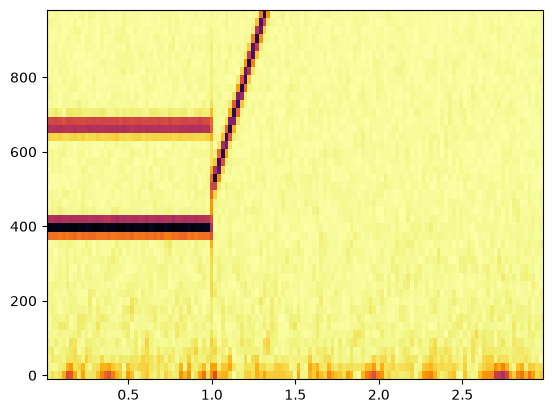

In [31]:
mystery.make_spectrogram(500).plot(high=1000)

Text(0.5, 1.0, 'Espectrograma de mystery.wav')

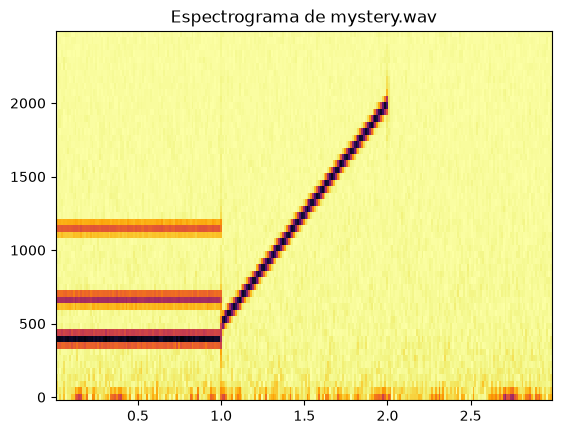

In [29]:
#spectrogram = wave.make_spectrogram(512)
#spectrogram.plot(high=2000)

mystery.make_spectrogram(250).plot(high=2500)
plt.title('Espectrograma de mystery.wav')

### Parte 1: 0–1 s

Se observan tres líneas horizontales en 400 Hz, 670 Hz y 1150 Hz. Como son frecuencias constantes y no aparecen sus armónicos, esta sección es una suma de tres señales cosenoidales conformado por tonos puros.

Text(0.5, 1.0, 'Parte 1: espectro de los tonos constantes')

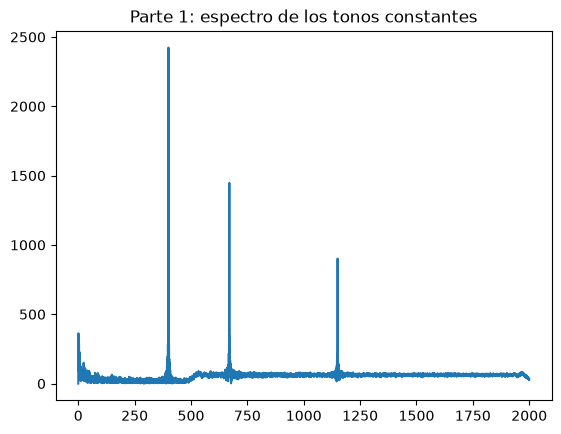

In [ ]:
part1 = mystery.segment()
spectrum1 = part1.make_spectrum()
spectrum1.plot(high=2000)

plt.title('Parte 1: espectro de los tonos constantes')

### Parte 2: 1–2 s

La línea inclinada del espectrograma muestra que la frecuencia aumenta con el tiempo. La señal comienza cerca de 400 Hz y termina cerca de 2000 Hz; por lo tanto, es un **chirp lineal**. Un único espectro no muestra bien este cambio, por eso el espectrograma es la herramienta principal en este caso.

Text(0.5, 1.0, 'Parte 2: oscilación al inicio y al final')

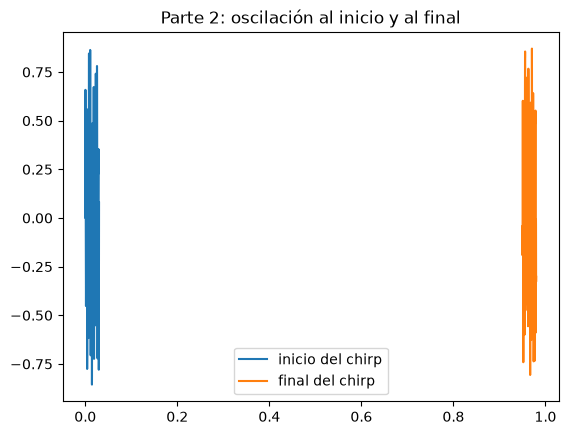

In [40]:
part2 = mystery.segment()
part2.segment(start=0, duration=0.03).plot(label='inicio del chirp')
part2.segment(start=0.95, duration=0.03).plot(label='final del chirp')

plt.legend()
plt.title('Parte 2: oscilación al inicio y al final')

### Parte 3: 2–3 s

Primero separamos los segmentos para trabajar con el intervalo 2-3 segundos.

Text(0.5, 1.0, 'Parte 3: segmento temporal del ruido')

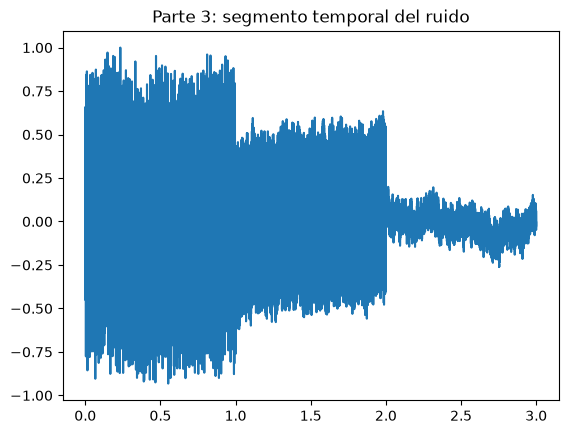

In [ ]:
part3 = mystery.plot()
plt.title('Parte 3: segmento temporal del ruido')

Veamos el mismo segmento pero entre 2-3s de intervalo

Text(0.5, 1.0, 'Parte 3: segmento temporal del ruido 2-3s')

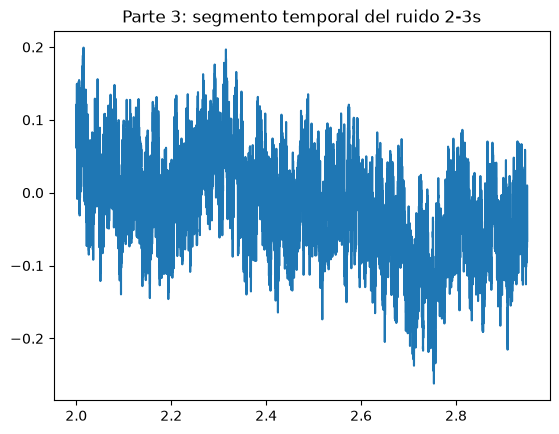

In [61]:
part3 = mystery.segment(start=2, duration=0.95)

part3.segment().plot()
plt.title('Parte 3: segmento temporal del ruido 2-3s')

Text(0.5, 1.0, 'Parte 3: espectro de amplitud')

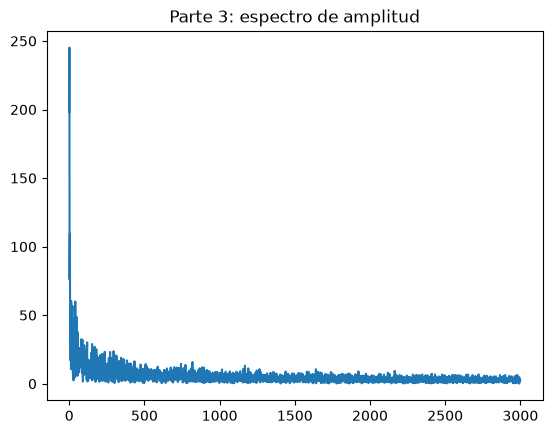

In [48]:
spectrum3 = part3.make_spectrum()
spectrum3.plot(high=3000)
plt.title('Parte 3: espectro de amplitud')

Pendiente estimada: -1.02
Pendiente cercana a -1: ruido rosa, con potencia aproximadamente 1/f.


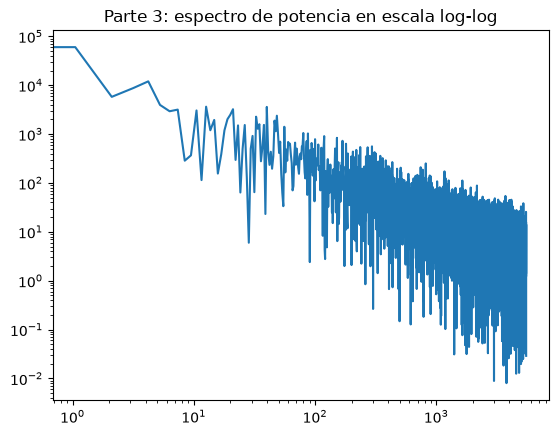

In [63]:
spectrum3.plot_power()
plt.xscale('log')
plt.yscale('log')
plt.title('Parte 3: espectro de potencia en escala log-log')

ajuste = spectrum3.estimate_slope()
print('Pendiente estimada:', round(ajuste.slope, 2))
print('Pendiente cercana a -1: ruido rosa, con potencia aproximadamente 1/f.')

Este fue el procedimiento a seguir: aislamos el tramo, observamos en el tiempo, verificamos que no hay picos periódicos y medimos la pendiente de su potencia. 

Con esto, obtuvimos una pendiente cercana a -1 corresponde a potencia proporcional a 1/f, característica del **ruido rosa**, donde contiene más energía en bajas frecuencias y su pendiente medida es cercana a -1.

**Conclusión pregunta 1:**

- De 0 a 1 s: suma de tres tonos cosenoidales de **400 Hz, 670 Hz y 1150 Hz**.
- De 1 a 2 s: **chirp lineal** que aumenta aproximadamente de **400 Hz a 2000 Hz**.
- De 2 a 3 s: **ruido rosa**, pues su potencia decae aproximadamente como $1/f$.

---
## Pregunta 2

La señal `pregunta.wav` contiene tres secciones. Se debe identificar el tipo de señal presente en cada una y justificar la respuesta.

### Solución

Primero, cargaremos la señal para saber su duración, frecuencia de muestreo y sus posibles intervalos.

In [ ]:
#pregunta = thinkdsp.read_wave('pregunta.wav')
pregunta = thinkdsp.read_wave(str(base / 'pregunta.wav'))
pregunta.normalize()

print('Frecuencia de muestreo:', pregunta.framerate, 'Hz')
print('Duración:', pregunta.duration, 's')

pregunta.make_audio()

Frecuencia de muestreo: 10000 Hz
Duración: 1.5 s


Con esto sabemos que la frecuencia de muestreo es de 10000 Hz, con una duración de 1.5 segundos.

El espectrograma confirma que hay tres tramos de aproximadamente medio segundo. En espeífico, de entre 0-0.5, 0.5-1.2 y 1.2-1,5 segundos

Text(0.5, 1.0, 'Espectrograma de pregunta.wav')

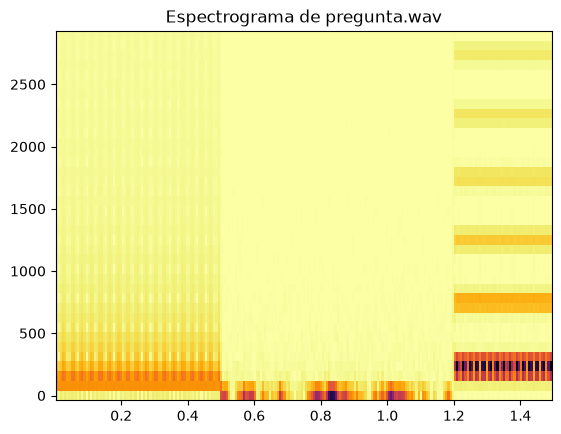

In [11]:
pregunta.make_spectrogram(128).plot(high=3000)
plt.title('Espectrograma de pregunta.wav')

### Parte 1: 0–0.5 s

Primero, visualizamos el espectro del primer intervalo.

Text(0.5, 1.0, 'Parte 1: espectro de la diente de sierra')

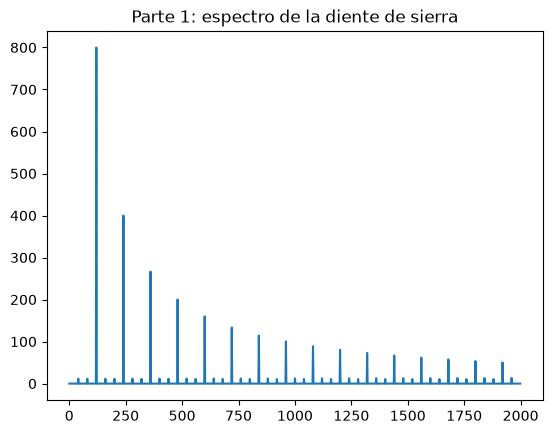

In [ ]:
wave1 = pregunta.segment()
wave1 = pregunta.segment(start=0, duration=0.5)

wave1.make_spectrum().plot(high=2000)
plt.title('Parte 1: espectro de la diente de sierra')

El espectro tiene una fundamental de 120 Hz y armónicos en todos sus múltiplos: 240, 360, 480 Hz, etc.
Por lo tanto, la presencia de armónicos pares e impares con amplitud decreciente corresponde a una **onda diente de sierra de 120 Hz**.

### Parte 2: 0.5–1.2 s

Vemos el segmento por completo de cómo funciona y a partir de esto, separamos el intervalo que nos interesa.

Text(0.5, 1.0, 'Parte 2: segmento temporal del ruido')

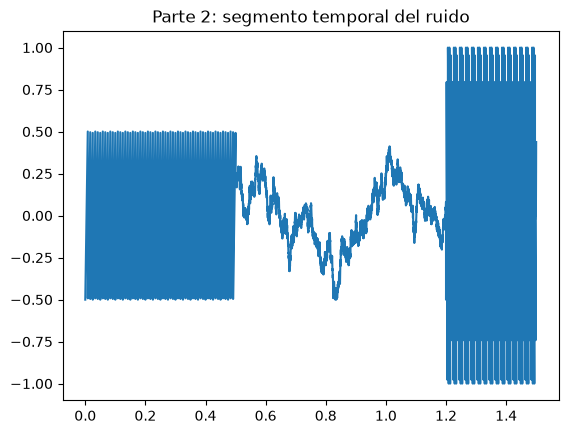

In [ ]:
wave2 = pregunta.plot()
plt.title('Parte 2: segmento temporal del ruido')

Text(0.5, 1.0, 'Parte 2: segmento temporal del ruido')

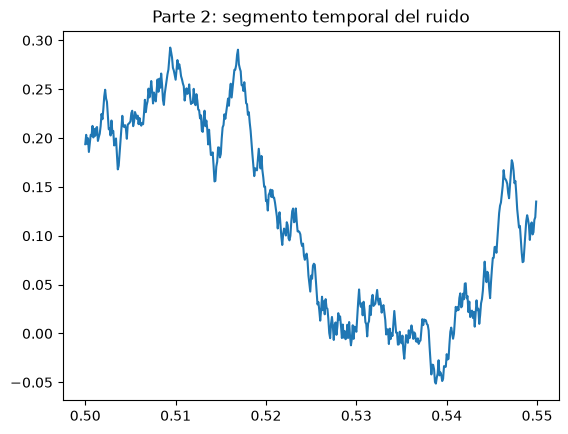

In [ ]:
# Aislamos la segunda sección, desde 0.5 s hasta 1 s.
wave2 = pregunta.segment(start=0.5, duration=0.5)

# Defino una ventana corta de la señal en el tiempo.
wave2.segment(start=0, duration=0.05).plot()
plt.title('Parte 2: segmento temporal del ruido')

Text(0.5, 1.0, 'Parte 2: espectro de amplitud')

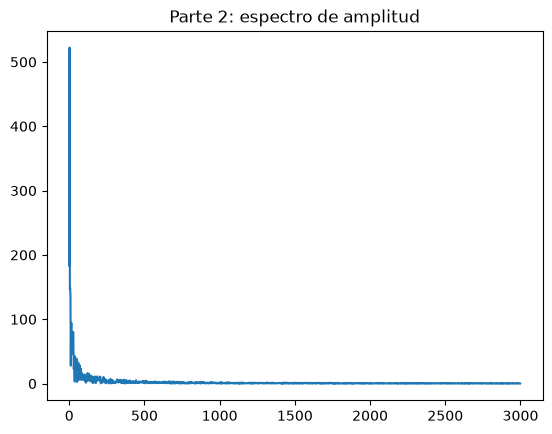

In [71]:
spectrum_wave2 = wave2.make_spectrum()
spectrum_wave2.plot(high=3000)
plt.title('Parte 2: espectro de amplitud')

Anteriormente definimos el segmento temporal en el intervalo que nos interesa. Con el espectro comprobamos que no hay picos periódicos ni armónicos definidos.

Pendiente estimada: -1.83
Pendiente cercana a -2: ruido browniano, con potencia aproximadamente 1/f².


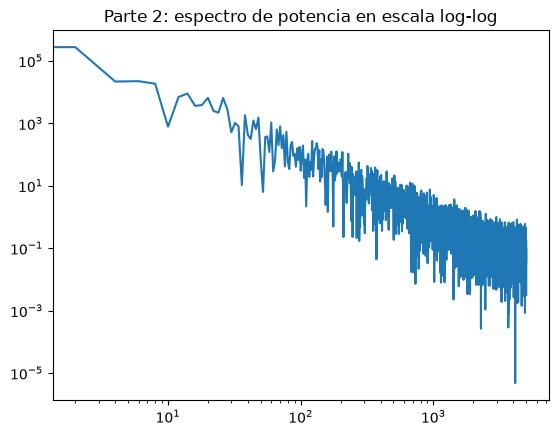

In [74]:
spectrum_wave2.plot_power()
plt.xscale('log')
plt.yscale('log')
plt.title('Parte 2: espectro de potencia en escala log-log')

ajuste = spectrum_wave2.estimate_slope()
print('Pendiente estimada:', round(ajuste.slope, 2))
print('Pendiente cercana a -2: ruido browniano, con potencia aproximadamente 1/f².')

Aislamos el tramo y comprobamos que es ruido: su forma temporal es irregular, su espectro no tiene una fundamental y su potencia se concentra en bajas frecuencias. La pendiente log-log cercana a -2 permite identificarlo como **ruido browniano** o rojo, cuya potencia es aproximadamente proporcional a 1/f².

### Parte 3: 1.2–1.5s


Visualizaremos el espectro de este intervalo:

Text(0.5, 1.0, 'Parte 3: espectro de la señal combinada')

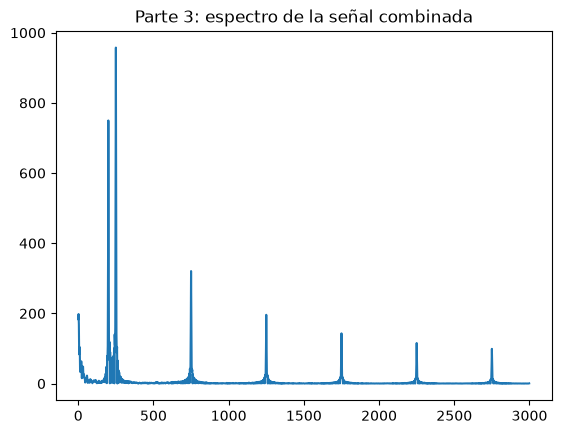

In [28]:
#wave3 = pregunta.segment()
wave3 = pregunta.segment(start=1, duration=0.5)
wave3.make_spectrum().plot(high=3000)
plt.title('Parte 3: espectro de la señal combinada')

El espectro muestra un pico aislado en 200 Hz aprox y además, una fundamental en 250 Hz con los armónicos impares 750, 1250, 1750 Hz, etc. El pico aislado corresponde a una cosenoide, donde la serie de armónicos impares corresponde a una onda cuadrada. Esta parte corresponde a una mezcla de **cosenoide de 200 Hz** y **onda cuadrada de 250 Hz**.

**Conclusión pregunta 2:**

- De 0 a 0.5 s: **onda diente de sierra de 120 Hz**.
- De 0.5 a 1 s: **ruido browniano** (pendiente espectral cercana a -2).
- De 1 a 1.5 s: suma de una **cosenoide de 200 Hz** y una **onda cuadrada de 250 Hz**.